# Linear Regression Forecasting

This notebook evaluates Linear Regression as an interpretable, feature-based demand forecasting model for the `FOODS`, `HOBBIES`, and `HOUSEHOLD` categories.

Using the same expanding-window, calendar-month validation framework as the baseline models, the notebook builds lag, rolling-average, calendar, time-trend, and Christmas features. Each model is retrained before a validation window and forecasts that window recursively so future features do not use actual future sales.

Main objectives:

1. Build a full Linear Regression model using historical-demand and calendar features.
2. Evaluate the model across the 13 monthly validation windows using MAE, RMSE, and WAPE.
3. Use permutation importance to identify which features contribute most to forecast accuracy.
4. Test whether removing weak features improves validation performance.
5. Compare the final Linear Regression result with the baseline forecasting models.

The test dataset remains untouched. Linear Regression model choices are made using validation results only; final test evaluation happens later in `07_model_comparison.ipynb`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance

import models_metrics

In [2]:
train_data = pd.read_parquet("data/processed/train_data.parquet")

validation_data = pd.read_parquet("data/processed/validation_data.parquet")

validation_windows = pd.read_parquet("data/processed/validation_windows.parquet")

In [3]:
development_data = (
    pd.concat(
        [
            train_data,
            validation_data
        ],
        ignore_index=True
    )
    .sort_values(["cat_id", "ds"])
    .reset_index(drop=True)
)

In [4]:
development_data

,unique_id,ds,y,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,sell_price,item_id,dept_id,cat_id,store_id,state_id
0,HOBBIES_1_004_CA_2,2011-01-29,6.0,nan,nan,nan,nan,0,0,0,4.34,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_2,CA
1,HOBBIES_1_004_CA_4,2011-01-29,1.0,nan,nan,nan,nan,0,0,0,4.34,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_4,CA
2,HOBBIES_1_004_TX_1,2011-01-29,1.0,nan,nan,nan,nan,0,0,0,4.34,HOBBIES_1_004,HOBBIES_1,HOBBIES,TX_1,TX
3,HOBBIES_1_004_TX_2,2011-01-29,1.0,nan,nan,nan,nan,0,0,0,4.34,HOBBIES_1_004,HOBBIES_1,HOBBIES,TX_2,TX
4,HOBBIES_1_004_WI_1,2011-01-29,2.0,nan,nan,nan,nan,0,0,0,4.34,HOBBIES_1_004,HOBBIES_1,HOBBIES,WI_1,WI
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36537629,FOODS_3_827_TX_2,2015-06-20,0.0,nan,nan,nan,nan,0,0,0,1.00,FOODS_3_827,FOODS_3,FOODS,TX_2,TX
36537630,FOODS_3_827_TX_3,2015-06-20,0.0,nan,nan,nan,nan,0,0,0,1.00,FOODS_3_827,FOODS_3,FOODS,TX_3,TX
36537631,FOODS_3_827_WI_1,2015-06-20,6.0,nan,nan,nan,nan,0,0,0,1.00,FOODS_3_827,FOODS_3,FOODS,WI_1,WI
36537632,FOODS_3_827_WI_2,2015-06-20,0.0,nan,nan,nan,nan,0,0,0,1.00,FOODS_3_827,FOODS_3,FOODS,WI_2,WI


In [5]:
development_daily = (
    development_data
    .groupby(
        ["cat_id", "ds"],
        observed=True,
        as_index=False
    )
    .agg(y=("y", "sum"))
    .sort_values(["cat_id", "ds"])
    .reset_index(drop=True)
)

development_daily

,cat_id,ds,y
0,HOBBIES,2011-01-29,3764.0
1,HOBBIES,2011-01-30,3357.0
2,HOBBIES,2011-01-31,2682.0
3,HOBBIES,2011-02-01,2669.0
4,HOBBIES,2011-02-02,1814.0
...,...,...,...
4807,FOODS,2015-06-16,21346.0
4808,FOODS,2015-06-17,20254.0
4809,FOODS,2015-06-18,22419.0
4810,FOODS,2015-06-19,24540.0


In [6]:
featured_data = development_daily.sort_values(["cat_id", "ds"]).copy()

# Lags we will use 
for lag in [1, 7, 14, 28]:
    featured_data[f"lag_{lag}"] = (
        featured_data
        .groupby("cat_id", observed=True)["y"]
        .shift(lag)
    )
# Rolling features use only information available before the date
featured_data["rolling_mean_7"] = (
    featured_data
    .groupby("cat_id", observed=True)["y"]
    .transform(
        lambda series:
            series.shift(1).rolling(7).mean()
    )
)

featured_data["rolling_mean_28"] = (
    featured_data
    .groupby("cat_id", observed=True)["y"]
    .transform(
        lambda series:
            series.shift(1).rolling(28).mean()
    )
)


In [7]:
# Calendar features
featured_data["day_of_week"] = featured_data["ds"].dt.dayofweek


featured_data["month"] = featured_data["ds"].dt.month

# Long-term trend
featured_data["time_index"] = (
    featured_data
    .groupby("cat_id", observed=True)
    .cumcount()
)

# Christmas indicator
featured_data["is_christmas"] = ((featured_data["ds"].dt.month.eq(12)& featured_data["ds"].dt.day.eq(25)).astype(int))

In [8]:
model_data = pd.get_dummies(
    featured_data,
    columns=[
        "day_of_week",
        "month"
    ],
    drop_first=True,
    dtype=int
)

In [9]:
model_data

,cat_id,ds,y,lag_1,lag_7,lag_14,lag_28,rolling_mean_7,rolling_mean_28,time_index,...,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12
0,HOBBIES,2011-01-29,3764.0,NaN,NaN,NaN,NaN,NaN,NaN,0,...,0,0,0,0,0,0,0,0,0,0
1,HOBBIES,2011-01-30,3357.0,3764.0,NaN,NaN,NaN,NaN,NaN,1,...,0,0,0,0,0,0,0,0,0,0
2,HOBBIES,2011-01-31,2682.0,3357.0,NaN,NaN,NaN,NaN,NaN,2,...,0,0,0,0,0,0,0,0,0,0
3,HOBBIES,2011-02-01,2669.0,2682.0,NaN,NaN,NaN,NaN,NaN,3,...,0,0,0,0,0,0,0,0,0,0
4,HOBBIES,2011-02-02,1814.0,2669.0,NaN,NaN,NaN,NaN,NaN,4,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4807,FOODS,2015-06-16,21346.0,34524.0,26624.0,24951.0,19435.0,28488.285714,24861.857143,1599,...,0,0,0,1,0,0,0,0,0,0
4808,FOODS,2015-06-17,20254.0,21346.0,23633.0,24806.0,19514.0,27734.285714,24930.107143,1600,...,0,0,0,1,0,0,0,0,0,0
4809,FOODS,2015-06-18,22419.0,20254.0,24558.0,22797.0,19400.0,27251.571429,24956.535714,1601,...,0,0,0,1,0,0,0,0,0,0
4810,FOODS,2015-06-19,24540.0,22419.0,27193.0,26735.0,22834.0,26946.000000,25064.357143,1602,...,0,0,0,1,0,0,0,0,0,0


In [10]:
base_features = [
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_28",
    "rolling_mean_7",
    "rolling_mean_28",
    "time_index",
    "is_christmas"
]

calendar_features = [
    column
    for column in model_data.columns
    if (
        column.startswith("day_of_week_")
        or column.startswith("month_")
    )
]

feature_columns = (
    base_features
    + calendar_features
)

In [11]:
category = "FOODS"

window = validation_windows.iloc[0]

category_data = development_daily[
    development_daily["cat_id"] == category
].copy()

train = category_data[
    category_data["ds"] <= window["train_end"]
].copy()

validation = category_data[
    category_data["ds"].between(
        window["validation_start"],
        window["validation_end"]
    )
].copy()

print(
    "Train:",
    train["ds"].min().date(),
    "to",
    train["ds"].max().date()
)

print(
    "Validation:",
    validation["ds"].min().date(),
    "to",
    validation["ds"].max().date()
)

print("Forecast days:", len(validation))

Train: 2011-01-29 to 2014-06-20
Validation: 2014-06-21 to 2014-06-30
Forecast days: 10


In [12]:
train_model_data = model_data[
    (model_data["cat_id"] == category)
    & (model_data["ds"] <= window["train_end"])].dropna(
    subset=base_features).copy()

X_train = train_model_data[feature_columns]

y_train = train_model_data["y"]

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

linear_model = LinearRegression()

linear_model.fit(
    X_train_scaled,
    y_train
)

print("Training rows:", len(X_train))
print("Features:", len(feature_columns))

Training rows: 1211
Features: 25


In [13]:
history = train["y"].astype(float).tolist()

forecasts = []

for forecast_date in validation["ds"]:
    forecast_features = pd.DataFrame(
        {
            "lag_1": [history[-1]],
            "lag_7": [history[-7]],
            "lag_14": [history[-14]],
            "lag_28": [history[-28]],
            "rolling_mean_7": [
                np.mean(history[-7:])
            ],
            "rolling_mean_28": [
                np.mean(history[-28:])
            ],
            "day_of_week": [
                forecast_date.dayofweek
            ],
            "month": [
                forecast_date.month
            ],
            "time_index": [len(history)],
            "is_christmas": [
                int(
                    forecast_date.month == 12
                    and forecast_date.day == 25
                )
            ],
        }
    )

    forecast_features = pd.get_dummies(
        forecast_features,
        columns=["day_of_week", "month"],
        dtype=int,
    )

    forecast_features = forecast_features.reindex(
        columns=feature_columns,
        fill_value=0,
    )

    prediction = linear_model.predict(
        scaler.transform(forecast_features)
    )[0]

    prediction = max(0, prediction)

    forecasts.append(prediction)

    # Add the prediction, not the future actual value.
    history.append(prediction)

forecasts = np.asarray(forecasts)

forecasts

array([30079.26942366, 29499.8142744 , 24585.40281424, 22869.85284833,
       22263.7190364 , 22191.8079563 , 24919.7962386 , 29608.40300792,
       30663.57474663, 25960.35985037])

In [14]:
first_window_metrics = (
    models_metrics
    .calculate_validation_metrics(
        actual=validation["y"],
        forecast=forecasts,
    )
)

first_window_metrics

{'MAE': np.float64(2238.300019684148),
 'RMSE': np.float64(2384.749578973585),
 'WAPE (%)': np.float64(9.316196353452517)}

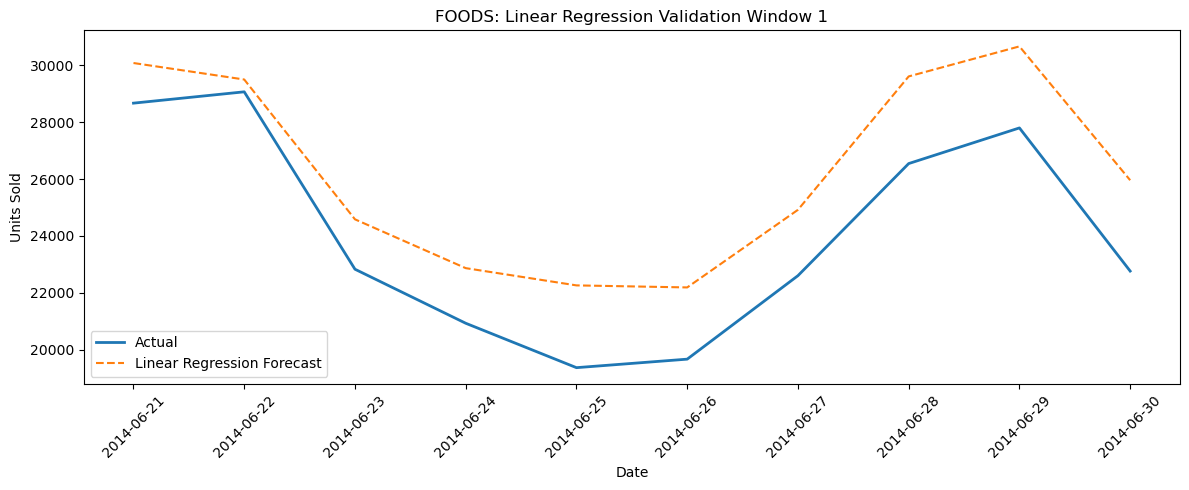

In [15]:
plt.figure(figsize=(12, 5))

plt.plot(
    validation["ds"],
    validation["y"],
    label="Actual",
    linewidth=2,
)

plt.plot(
    validation["ds"],
    forecasts,
    label="Linear Regression Forecast",
    linestyle="--",
)

plt.title(
    f"{category}: Linear Regression "
    f"Validation Window {int(window['window'])}"
)

plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [16]:
linear_metric_records = []
linear_forecast_records = []
importance_records = []

for category, category_data in development_daily.groupby(
    "cat_id",
    observed=True,
):
    category_data = (
        category_data
        .sort_values("ds")
        .reset_index(drop=True)
    )

    for _, window in validation_windows.iterrows():
        train = category_data[
            category_data["ds"] <= window["train_end"]
        ].copy()

        validation = category_data[
            category_data["ds"].between(
                window["validation_start"],
                window["validation_end"],
            )
        ].copy()

        train_model_data = model_data[
            (
                model_data["cat_id"] == category
            )
            & (
                model_data["ds"] <= window["train_end"]
            )
        ].dropna(
            subset=base_features
        ).copy()

        X_train = train_model_data[feature_columns]
        y_train = train_model_data["y"]

        scaler = StandardScaler()

        X_train_scaled = scaler.fit_transform(
            X_train
        )

        linear_model = LinearRegression()

        linear_model.fit(
            X_train_scaled,
            y_train,
        )

        history = train["y"].astype(float).tolist()

        forecasts = []
        recursive_feature_rows = []

        for forecast_date in validation["ds"]:
            forecast_features = pd.DataFrame(
                {
                    "lag_1": [history[-1]],
                    "lag_7": [history[-7]],
                    "lag_14": [history[-14]],
                    "lag_28": [history[-28]],
                    "rolling_mean_7": [
                        np.mean(history[-7:])
                    ],
                    "rolling_mean_28": [
                        np.mean(history[-28:])
                    ],
                    "day_of_week": [
                        forecast_date.dayofweek
                    ],
                    "month": [
                        forecast_date.month
                    ],
                    "time_index": [len(history)],
                    "is_christmas": [
                        int(
                            forecast_date.month == 12
                            and forecast_date.day == 25
                        )
                    ],
                }
            )

            forecast_features = pd.get_dummies(
                forecast_features,
                columns=["day_of_week", "month"],
                dtype=int,
            )

            forecast_features = forecast_features.reindex(
                columns=feature_columns,
                fill_value=0,
            )

            prediction = linear_model.predict(
                scaler.transform(forecast_features)
            )[0]

            prediction = max(0, prediction)

            forecasts.append(prediction)

            recursive_feature_rows.append(
                forecast_features
            )

            history.append(prediction)

        actual = validation["y"].to_numpy(
            dtype=float
        )

        forecasts = np.asarray(forecasts)

        metrics = models_metrics.calculate_validation_metrics(
            actual=actual,
            forecast=forecasts,
        )

        print(
            f"{category} | "
            f"Window {int(window['window'])} | "
            f"{len(validation)} forecast days"
        )

        linear_metric_records.append(
            {
                "cat_id": category,
                "window": int(window["window"]),
                "train_end": window["train_end"],
                "validation_start":
                    window["validation_start"],
                "validation_end":
                    window["validation_end"],
                "forecast_days": len(validation),
                "Model": "Linear Regression (Full)",
                "MAE": metrics["MAE"],
                "RMSE": metrics["RMSE"],
                "WAPE (%)": metrics["WAPE (%)"],
            }
        )

        for date, actual_value, forecast_value in zip(
            validation["ds"],
            actual,
            forecasts,
        ):
            linear_forecast_records.append(
                {
                    "cat_id": category,
                    "window": int(window["window"]),
                    "ds": date,
                    "Model": "Linear Regression (Full)",
                    "actual": actual_value,
                    "forecast": forecast_value,
                }
            )

        recursive_features = pd.concat(
            recursive_feature_rows,
            ignore_index=True,
        )

        importance = permutation_importance(
            linear_model,
            scaler.transform(recursive_features),
            actual,
            scoring="neg_mean_absolute_error",
            n_repeats=5,
            random_state=42,
        )

        for feature, score in zip(
            feature_columns,
            importance.importances_mean,
        ):
            importance_records.append(
                {
                    "cat_id": category,
                    "window": int(window["window"]),
                    "feature": feature,
                    "importance": score,
                }
            )

HOBBIES | Window 1 | 10 forecast days


HOBBIES | Window 2 | 31 forecast days


HOBBIES | Window 3 | 31 forecast days
HOBBIES | Window 4 | 30 forecast days


HOBBIES | Window 5 | 31 forecast days


HOBBIES | Window 6 | 30 forecast days
HOBBIES | Window 7 | 31 forecast days


...

HOUSEHOLD | Window 7 | 31 forecast days


HOUSEHOLD | Window 8 | 31 forecast days
HOUSEHOLD | Window 9 | 28 forecast days
HOUSEHOLD | Window 10 | 31 forecast days
HOUSEHOLD | Window 11 | 30 forecast days


HOUSEHOLD | Window 12 | 31 forecast days
HOUSEHOLD | Window 13 | 20 forecast days
FOODS | Window 1 | 10 forecast days
FOODS | Window 2 | 31 forecast days
FOODS | Window 3 | 31 forecast days


FOODS | Window 4 | 30 forecast days
FOODS | Window 5 | 31 forecast days
FOODS | Window 6 | 30 forecast days
FOODS | Window 7 | 31 forecast days
FOODS | Window 8 | 31 forecast days


FOODS | Window 9 | 28 forecast days
FOODS | Window 10 | 31 forecast days
FOODS | Window 11 | 30 forecast days
FOODS | Window 12 | 31 forecast days
FOODS | Window 13 | 20 forecast days


In [17]:
linear_regression_metrics = pd.DataFrame(
    linear_metric_records
)

linear_regression_forecasts = pd.DataFrame(
    linear_forecast_records
)

linear_regression_importance = pd.DataFrame(
    importance_records
)

linear_regression_metrics.groupby(
    ["cat_id", "Model"],
    observed=True,
)["window"].nunique()

cat_id     Model                   
FOODS      Linear Regression (Full)    13
HOBBIES    Linear Regression (Full)    13
HOUSEHOLD  Linear Regression (Full)    13
Name: window, dtype: int64

In [18]:
linear_regression_summary = (
    linear_regression_metrics
    .groupby(
        ["cat_id", "Model"],
        observed=True,
        as_index=False,
    )
    .agg(
        Mean_MAE=("MAE", "mean"),
        Mean_RMSE=("RMSE", "mean"),
        Mean_WAPE=("WAPE (%)", "mean"),
        Std_WAPE=("WAPE (%)", "std"),
        Best_WAPE=("WAPE (%)", "min"),
        Worst_WAPE=("WAPE (%)", "max"),
    )
    .round(2)
)

linear_regression_summary

,cat_id,Model,Mean_MAE,Mean_RMSE,Mean_WAPE,Std_WAPE,Best_WAPE,Worst_WAPE
0,FOODS,Linear Regression (Full),1798.67,2288.85,7.42,1.94,4.81,12.10
1,HOBBIES,Linear Regression (Full),223.04,290.39,6.50,1.48,4.73,9.14
2,HOUSEHOLD,Linear Regression (Full),580.68,751.21,6.91,1.85,4.73,10.33


In [19]:
importance_summary = (
    linear_regression_importance
    .groupby(
        ["cat_id", "feature"],
        observed=True,
        as_index=False,
    )
    .agg(
        Mean_Importance=("importance", "mean"),
    )
    .sort_values(
        ["cat_id", "Mean_Importance"],
        ascending=[True, False],
    )
)

importance_summary

,cat_id,feature,Mean_Importance
4,FOODS,day_of_week_5,8.983894e+02
5,FOODS,day_of_week_6,6.697639e+02
9,FOODS,lag_28,4.398697e+02
7,FOODS,lag_1,3.758531e+02
3,FOODS,day_of_week_4,2.857043e+02
...,...,...,...
70,HOUSEHOLD,month_8,2.623542e-14
71,HOUSEHOLD,month_9,2.623542e-14
74,HOUSEHOLD,time_index,-1.748830e-01
72,HOUSEHOLD,rolling_mean_28,-8.143649e-01


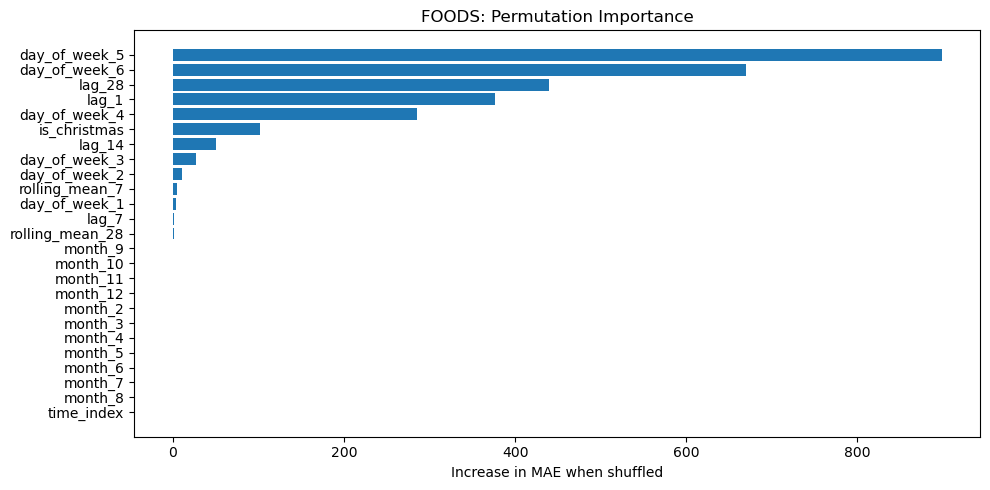

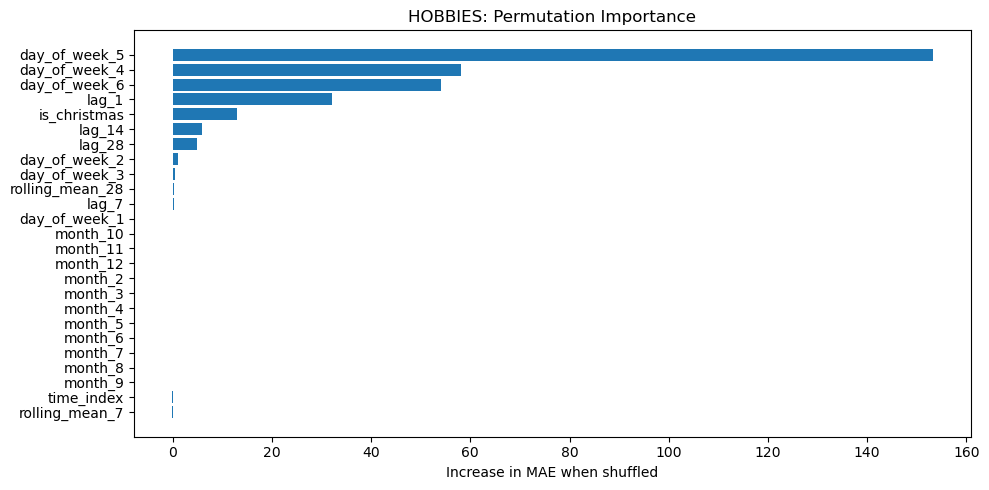

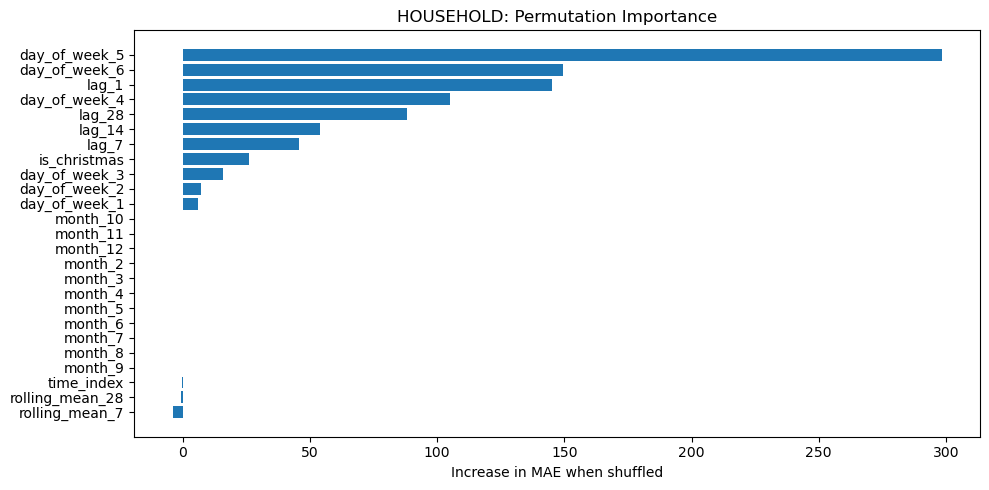

In [20]:
for category in importance_summary["cat_id"].unique():
    plot_data = importance_summary[
        importance_summary["cat_id"] == category
    ].sort_values("Mean_Importance")

    plt.figure(figsize=(10, 5))

    plt.barh(
        plot_data["feature"],
        plot_data["Mean_Importance"],
    )

    plt.title(
        f"{category}: Permutation Importance"
    )

    plt.xlabel(
        "Increase in MAE when shuffled"
    )

    plt.tight_layout()
    plt.show()

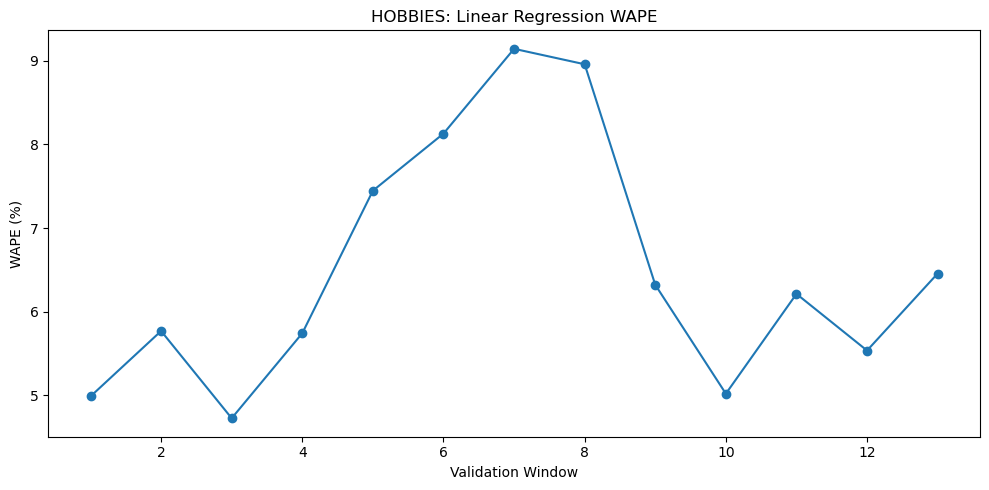

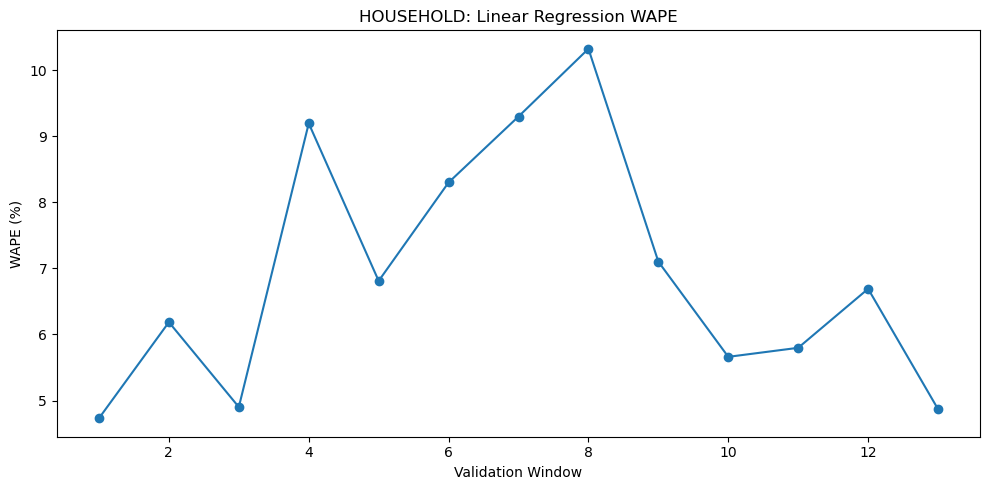

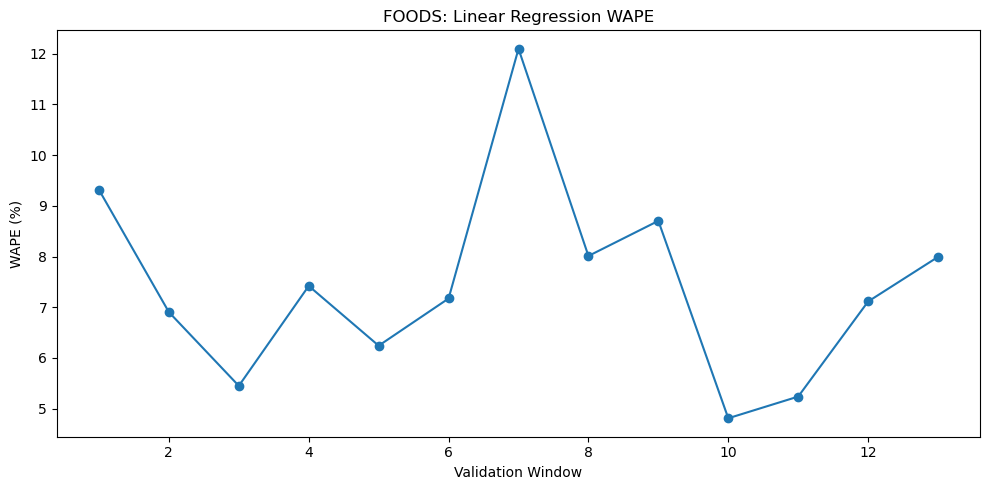

In [21]:
for category in linear_regression_metrics[
    "cat_id"
].unique():

    plot_data = linear_regression_metrics[
        linear_regression_metrics["cat_id"] == category
    ]

    plt.figure(figsize=(10, 5))

    plt.plot(
        plot_data["window"],
        plot_data["WAPE (%)"],
        marker="o",
    )

    plt.title(
        f"{category}: Linear Regression WAPE"
    )

    plt.xlabel("Validation Window")
    plt.ylabel("WAPE (%)")
    plt.tight_layout()
    plt.show()

In [22]:
# removing less than or equal to zero importance

feature_selection = importance_summary.copy()

feature_selection["remove"] = (
    feature_selection["Mean_Importance"] <= 0
)

feature_selection

,cat_id,feature,Mean_Importance,remove
4,FOODS,day_of_week_5,8.983894e+02,False
5,FOODS,day_of_week_6,6.697639e+02,False
9,FOODS,lag_28,4.398697e+02,False
7,FOODS,lag_1,3.758531e+02,False
3,FOODS,day_of_week_4,2.857043e+02,False
...,...,...,...,...
70,HOUSEHOLD,month_8,2.623542e-14,False
71,HOUSEHOLD,month_9,2.623542e-14,False
74,HOUSEHOLD,time_index,-1.748830e-01,True
72,HOUSEHOLD,rolling_mean_28,-8.143649e-01,True


In [23]:
features_to_remove_by_category = (
    feature_selection[
        feature_selection["remove"]
    ]
    .groupby(
        "cat_id",
        observed=True,
    )["feature"]
    .apply(list)
    .to_dict()
)

features_to_remove_by_category

{'FOODS': ['month_10',
  'month_11',
  'month_12',
  'month_2',
  'month_3',
  'month_4',
  'month_5',
  'month_6',
  'month_7',
  'month_8',
  'month_9',
  'time_index'],
 'HOBBIES': ['month_10',
  'month_11',
  'month_12',
  'month_2',
  'month_3',
  'month_4',
  'month_5',
  'month_6',
  'month_7',
  'month_8',
  'month_9',
  'time_index',
  'rolling_mean_7'],
 'HOUSEHOLD': ['time_index', 'rolling_mean_28', 'rolling_mean_7']}

In [24]:
reduced_metric_records = []
reduced_forecast_records = []

for category, category_data in development_daily.groupby(
    "cat_id",
    observed=True,
):
    category_data = (
        category_data
        .sort_values("ds")
        .reset_index(drop=True)
    )

    category_feature_columns = [
        feature
        for feature in feature_columns
        if feature not in features_to_remove_by_category.get(
            category,
            []
        )
    ]

    for _, window in validation_windows.iterrows():
        train = category_data[
            category_data["ds"] <= window["train_end"]
        ].copy()

        validation = category_data[
            category_data["ds"].between(
                window["validation_start"],
                window["validation_end"],
            )
        ].copy()

        train_model_data = model_data[
            (
                model_data["cat_id"] == category
            )
            & (
                model_data["ds"] <= window["train_end"]
            )
        ].dropna(
            subset=base_features
        ).copy()

        X_train = train_model_data[
            category_feature_columns
        ]

        y_train = train_model_data["y"]

        scaler = StandardScaler()

        X_train_scaled = scaler.fit_transform(
            X_train
        )

        linear_model = LinearRegression()

        linear_model.fit(
            X_train_scaled,
            y_train,
        )

        history = train["y"].astype(float).tolist()

        forecasts = []

        for forecast_date in validation["ds"]:
            forecast_features = pd.DataFrame(
                {
                    "lag_1": [history[-1]],
                    "lag_7": [history[-7]],
                    "lag_14": [history[-14]],
                    "lag_28": [history[-28]],
                    "rolling_mean_7": [
                        np.mean(history[-7:])
                    ],
                    "rolling_mean_28": [
                        np.mean(history[-28:])
                    ],
                    "day_of_week": [
                        forecast_date.dayofweek
                    ],
                    "month": [
                        forecast_date.month
                    ],
                    "time_index": [len(history)],
                    "is_christmas": [
                        int(
                            forecast_date.month == 12
                            and forecast_date.day == 25
                        )
                    ],
                }
            )

            forecast_features = pd.get_dummies(
                forecast_features,
                columns=["day_of_week", "month"],
                dtype=int,
            )

            forecast_features = forecast_features.reindex(
                columns=category_feature_columns,
                fill_value=0,
            )

            prediction = linear_model.predict(
                scaler.transform(forecast_features)
            )[0]

            prediction = max(0, prediction)

            forecasts.append(prediction)

            history.append(prediction)

        actual = validation["y"].to_numpy(
            dtype=float
        )

        metrics = models_metrics.calculate_validation_metrics(
            actual=actual,
            forecast=forecasts,
        )

        print(
            f"{category} | "
            f"Window {int(window['window'])}"
        )

        reduced_metric_records.append(
            {
                "cat_id": category,
                "window": int(window["window"]),
                "Model": "Linear Regression (Reduced)",
                "MAE": metrics["MAE"],
                "RMSE": metrics["RMSE"],
                "WAPE (%)": metrics["WAPE (%)"],
            }
        )

        for date, actual_value, forecast_value in zip(
            validation["ds"],
            actual,
            forecasts,
        ):
            reduced_forecast_records.append(
                {
                    "cat_id": category,
                    "window": int(window["window"]),
                    "ds": date,
                    "Model": "Linear Regression (Reduced)",
                    "actual": actual_value,
                    "forecast": forecast_value,
                }
            )

HOBBIES | Window 1
HOBBIES | Window 2
HOBBIES | Window 3
HOBBIES | Window 4
HOBBIES | Window 5
HOBBIES | Window 6


HOBBIES | Window 7
HOBBIES | Window 8
HOBBIES | Window 9
HOBBIES | Window 10
HOBBIES | Window 11
HOBBIES | Window 12
HOBBIES | Window 13
HOUSEHOLD | Window 1


HOUSEHOLD | Window 2
HOUSEHOLD | Window 3
HOUSEHOLD | Window 4
HOUSEHOLD | Window 5
HOUSEHOLD | Window 6
HOUSEHOLD | Window 7
HOUSEHOLD | Window 8


HOUSEHOLD | Window 9
HOUSEHOLD | Window 10
HOUSEHOLD | Window 11
HOUSEHOLD | Window 12
HOUSEHOLD | Window 13
FOODS | Window 1
FOODS | Window 2
FOODS | Window 3


FOODS | Window 4
FOODS | Window 5
FOODS | Window 6
FOODS | Window 7
FOODS | Window 8
FOODS | Window 9


FOODS | Window 10
FOODS | Window 11
FOODS | Window 12
FOODS | Window 13


In [25]:
reduced_metrics = pd.DataFrame(
    reduced_metric_records
)

reduced_forecasts = pd.DataFrame(
    reduced_forecast_records
)

reduced_summary = (
    reduced_metrics
    .groupby(
        ["cat_id", "Model"],
        observed=True,
        as_index=False,
    )
    .agg(
        Mean_MAE=("MAE", "mean"),
        Mean_RMSE=("RMSE", "mean"),
        Mean_WAPE=("WAPE (%)", "mean"),
        Std_WAPE=("WAPE (%)", "std"),
        Best_WAPE=("WAPE (%)", "min"),
        Worst_WAPE=("WAPE (%)", "max"),
    )
    .round(2)
)

reduced_summary

,cat_id,Model,Mean_MAE,Mean_RMSE,Mean_WAPE,Std_WAPE,Best_WAPE,Worst_WAPE
0,FOODS,Linear Regression (Reduced),1730.43,2187.47,7.08,1.91,4.35,11.76
1,HOBBIES,Linear Regression (Reduced),241.42,311.54,7.03,2.52,3.63,11.86
2,HOUSEHOLD,Linear Regression (Reduced),591.65,774.63,7.03,2.21,3.66,12.17


In [26]:
all_linear_metrics = pd.concat(
    [
        linear_regression_metrics,
        reduced_metrics,
    ],
    ignore_index=True,
)

all_linear_forecasts = pd.concat(
    [
        linear_regression_forecasts,
        reduced_forecasts,
    ],
    ignore_index=True,
)

all_linear_summary = pd.concat(
    [
        linear_regression_summary,
        reduced_summary,
    ],
    ignore_index=True,
)

all_linear_summary

,cat_id,Model,Mean_MAE,Mean_RMSE,Mean_WAPE,Std_WAPE,Best_WAPE,Worst_WAPE
0,FOODS,Linear Regression (Full),1798.67,2288.85,7.42,1.94,4.81,12.10
1,HOBBIES,Linear Regression (Full),223.04,290.39,6.50,1.48,4.73,9.14
2,HOUSEHOLD,Linear Regression (Full),580.68,751.21,6.91,1.85,4.73,10.33
3,FOODS,Linear Regression (Reduced),1730.43,2187.47,7.08,1.91,4.35,11.76
4,HOBBIES,Linear Regression (Reduced),241.42,311.54,7.03,2.52,3.63,11.86
5,HOUSEHOLD,Linear Regression (Reduced),591.65,774.63,7.03,2.21,3.66,12.17


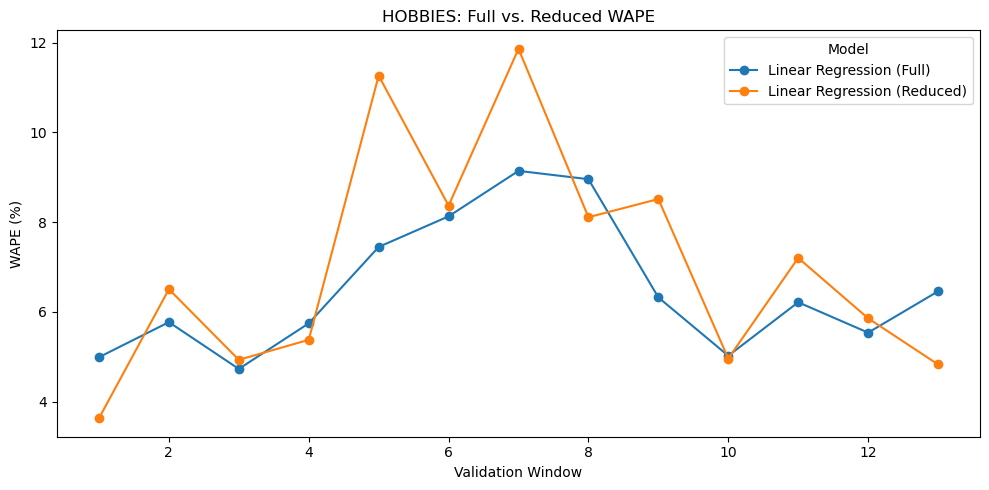

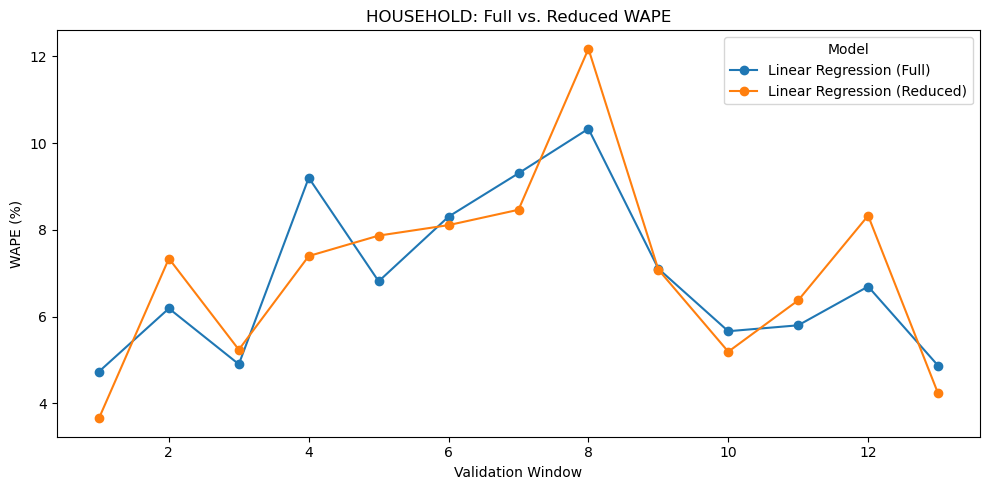

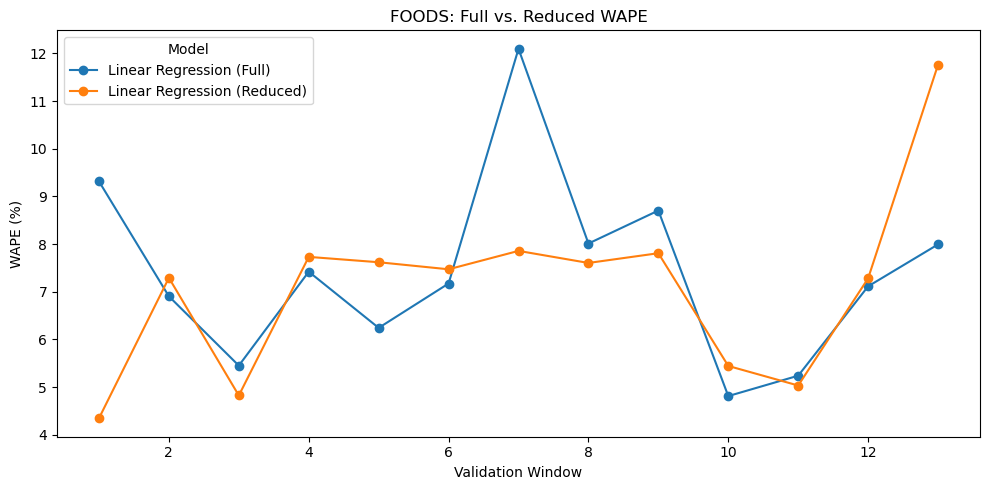

In [27]:
for category in all_linear_metrics["cat_id"].unique():
    plot_data = all_linear_metrics[
        all_linear_metrics["cat_id"] == category
    ]

    comparison = plot_data.pivot(
        index="window",
        columns="Model",
        values="WAPE (%)",
    )

    comparison.plot(
        marker="o",
        figsize=(10, 5),
        title=f"{category}: Full vs. Reduced WAPE",
    )

    plt.xlabel("Validation Window")
    plt.ylabel("WAPE (%)")
    plt.tight_layout()
    plt.show()

In [28]:
best_linear_models = (
    all_linear_summary
    .sort_values(
        ["cat_id", "Mean_WAPE"]
    )
    .groupby(
        "cat_id",
        observed=True,
    )
    .first()
    .reset_index()
)

best_linear_models

,cat_id,Model,Mean_MAE,Mean_RMSE,Mean_WAPE,Std_WAPE,Best_WAPE,Worst_WAPE
0,FOODS,Linear Regression (Reduced),1730.43,2187.47,7.08,1.91,4.35,11.76
1,HOBBIES,Linear Regression (Full),223.04,290.39,6.50,1.48,4.73,9.14
2,HOUSEHOLD,Linear Regression (Full),580.68,751.21,6.91,1.85,4.73,10.33


In [29]:
def plot_best_linear_model(category):
    best_model = best_linear_models.loc[
        best_linear_models["cat_id"] == category,
        "Model",
    ].iloc[0]

    plot_data = all_linear_forecasts[
        (
            all_linear_forecasts["cat_id"] == category
        )
        & (
            all_linear_forecasts["Model"] == best_model
        )
    ].sort_values("ds")

    plt.figure(figsize=(14, 6))

    plt.plot(
        plot_data["ds"],
        plot_data["actual"],
        label="Actual",
        linewidth=2,
    )

    plt.plot(
        plot_data["ds"],
        plot_data["forecast"],
        label=best_model,
        linestyle="--",
    )

    plt.title(
        f"{category}: Best Linear Regression Model"
    )

    plt.xlabel("Date")
    plt.ylabel("Units Sold")
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

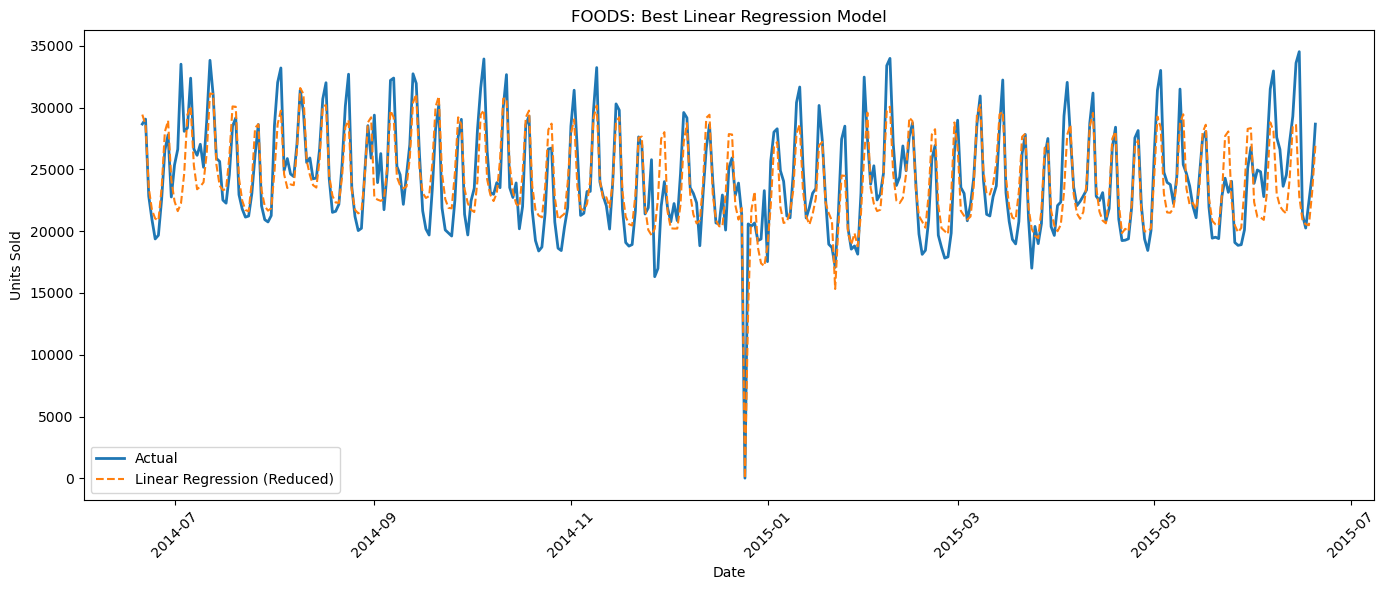

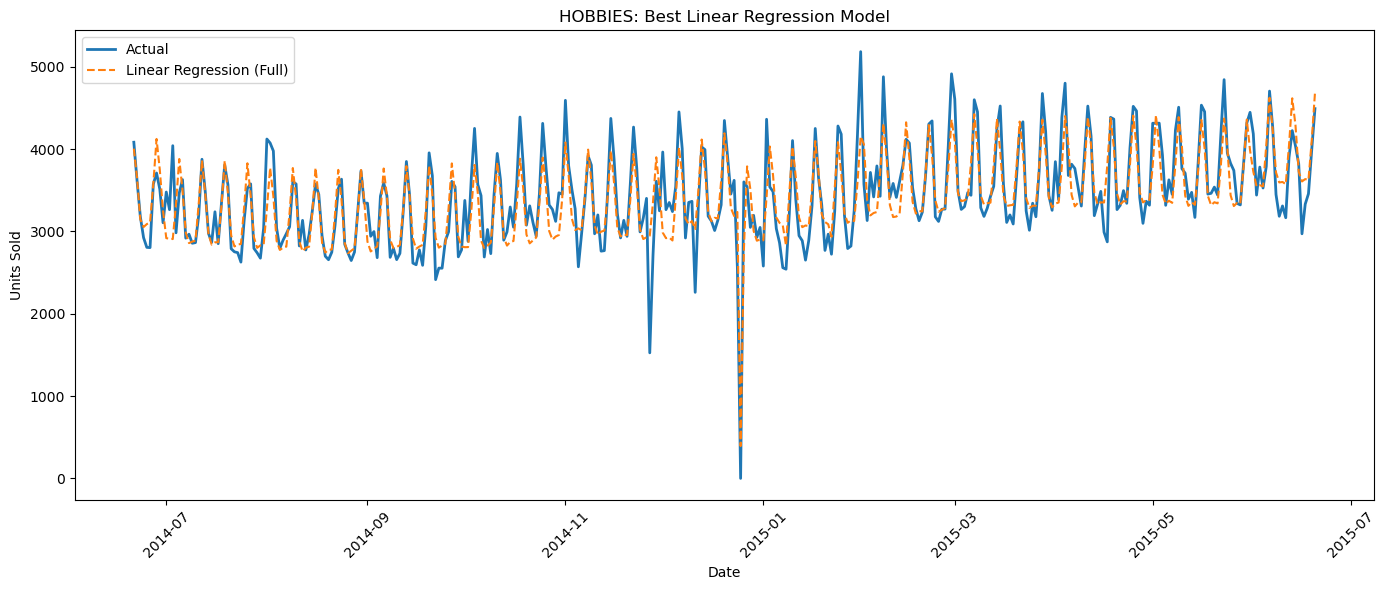

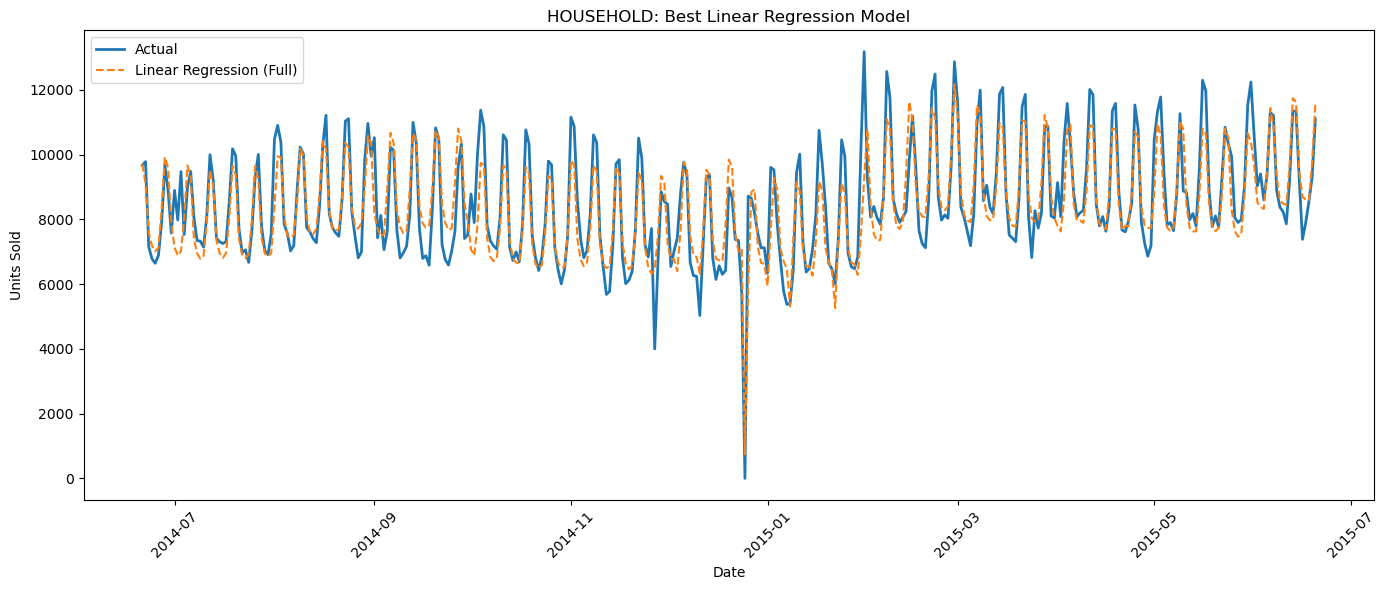

In [30]:
plot_best_linear_model("FOODS")
plot_best_linear_model("HOBBIES")
plot_best_linear_model("HOUSEHOLD")